<a href="https://colab.research.google.com/github/anjali22-lgtm/cancer-risk-prediction/blob/main/notebook/cancer_risk_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# cancer_risk_prediction


---



Saving cancer-risk-factors.csv to cancer-risk-factors (35).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Cancer_Type              2000 non-null   object 
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Ha

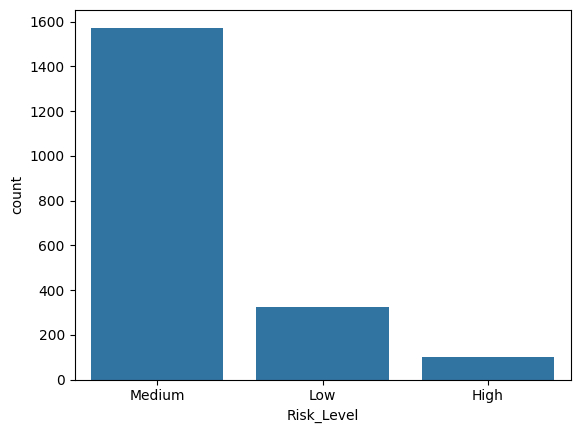

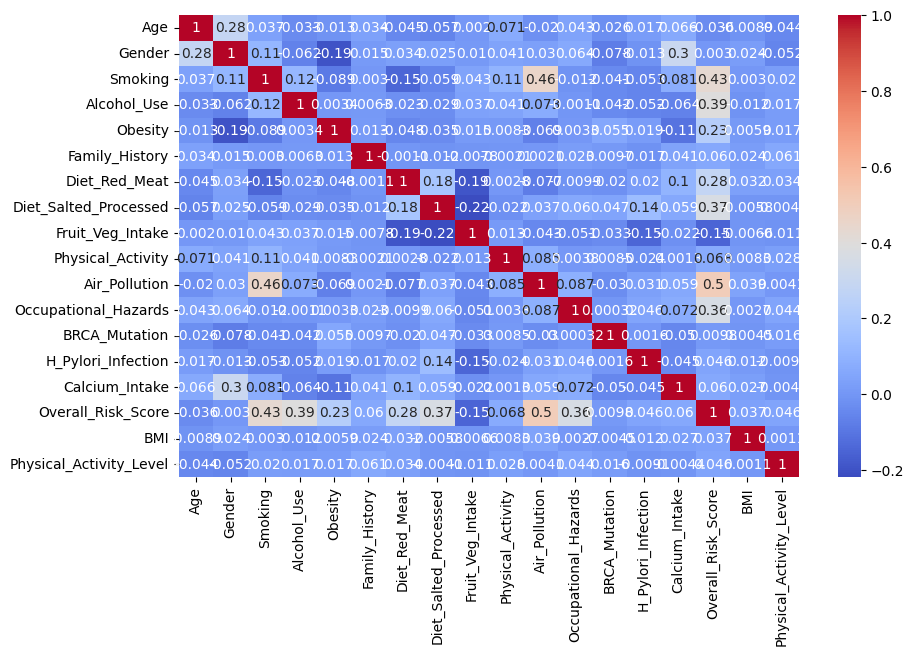

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[ 13   0   3]
 [  0  52   5]
 [  0   2 325]]
[[ 13   0   3]
 [  0  56   1]
 [  0   0 327]]
SMOTE Model Accuracy: 1.0
Cross Validation Scores: [0.99866489 1.         1.         0.9986631  0.9986631 ]
Mean CV Score: 0.999198217944782


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


from google.colab import files

uploaded = files.upload()

df = pd.read_csv('cancer-risk-factors.csv')
df.head()
df.shape
df.describe()
df.info()

df['Risk_Level'].value_counts()
sns.countplot(x='Risk_Level', data=df)
plt.show()

df.isnull().sum()

df.columns
df_numeric = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(),annot=True, cmap='coolwarm')
plt.show()

df.select_dtypes(include='object').columns

df = df.drop('Patient_ID', axis=1)  # or CO0168 column

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

    X = df.drop('Risk_Level', axis=1)
y = df['Risk_Level']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_rf)

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(confusion_matrix(y_test, y_pred_rf))


!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)

y_pred_smote = rf_model.predict(X_test)

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

from sklearn.metrics import accuracy_score

print("SMOTE Model Accuracy:", accuracy_score(y_test, y_pred_smote))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X_resampled, y_resampled, cv=5)

print("Cross Validation Scores:", scores)
print("Mean CV Score:", scores.mean())
